# Mô hình A — LLM Gốc (Không RAG, Không Fine-tune)

**Đề tài:** Xây dựng hệ thống hỏi đáp tiếng Việt — Luật Giao thông Đường bộ

| Cấu hình | LLM gốc | LLM fine-tuned |
|---|---|---|
| Không RAG | **A** | C |
| Có RAG | B | D |

**Model:** `meta-llama/Llama-3.2-3B` · **Method:** Zero-shot (không fine-tune) · **Data:** 349 cặp QA


## 0 · Cài đặt

In [1]:
!pip install -q peft accelerate evaluate rouge_score bert_score
!pip install -q matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00


## 1 · Mount Drive & Kiểm tra GPU

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import torch

assert torch.cuda.is_available(), 'Chua bat GPU! Vao Runtime -> Change runtime type -> T4 GPU'

gpu      = torch.cuda.get_device_name(0)
vram     = torch.cuda.get_device_properties(0).total_memory / 1e9
USE_BF16 = torch.cuda.get_device_capability()[0] >= 8

print(f'GPU      : {gpu}')
print(f'VRAM     : {vram:.1f} GB')
print(f'CUDA     : {torch.version.cuda}')
print(f'Precision: {"bf16" if USE_BF16 else "fp16"}')

Mounted at /content/drive
GPU      : Tesla T4
VRAM     : 15.6 GB
CUDA     : 12.8
Precision: fp16


## 2 · Upload / Load Data

In [3]:
import json, os

# Cach 1: Upload tu may
from google.colab import files
uploaded  = files.upload()
DATA_PATH = list(uploaded.keys())[0]

# Cach 2: Tu Drive (bo comment neu da co san)
# DATA_PATH = '/content/drive/MyDrive/data_no_RAG.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

print(f'Loaded    : {len(raw_data)} records')
print(f'Keys      : {list(raw_data[0].keys())}')
print(f'Sample Q  : {repr(raw_data[0]["Q"][:80])}')
print(f'Sample A  : {repr(raw_data[0]["A"][:80])}')

Saving data_no_RAG.json to data_no_RAG.json
Loaded    : 349 records
Keys      : ['Q', 'A']
Sample Q  : 'Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?'
Sample A  : 'Ngày 01 tháng 01 năm 2025'


## 3 · EDA — Khám phá dữ liệu

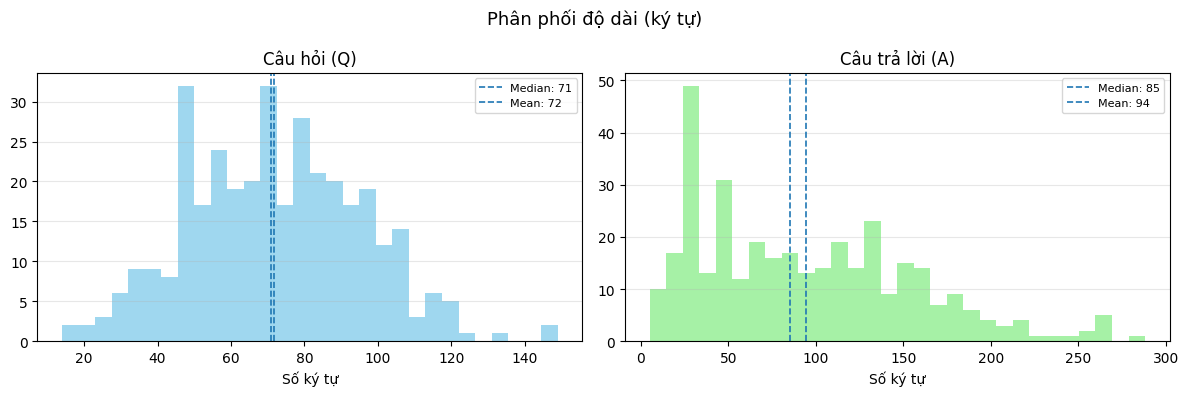

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Màu dùng cho biểu đồ
COLORS = ['skyblue', 'lightgreen', 'orange', 'mediumpurple', 'lightcoral']

# Chuyển dữ liệu JSON thành DataFrame
df = pd.DataFrame(raw_data)

# Tính số ký tự của câu hỏi và câu trả lời
df['q_chars'] = df['Q'].str.len()
df['a_chars'] = df['A'].str.len()

# Tính số từ của câu hỏi và câu trả lời
df['q_words'] = df['Q'].str.split().str.len()
df['a_words'] = df['A'].str.split().str.len()

# Plot 1: Phân phối độ dài câu hỏi và câu trả lời
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phân phối độ dài (ký tự)', fontsize=13)

for ax, col, color, label in zip(
    axes,
    ['q_chars', 'a_chars'],
    COLORS[:2],
    ['Câu hỏi (Q)', 'Câu trả lời (A)']
):
    ax.hist(df[col], bins=30, color=color, alpha=0.8)
    ax.axvline(df[col].median(), linestyle='--', linewidth=1.2, label=f'Median: {df[col].median():.0f}')
    ax.axvline(df[col].mean(),   linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.0f}')
    ax.set_title(label)
    ax.set_xlabel('Số ký tự')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_1_length.png', dpi=130, bbox_inches='tight')
plt.show()

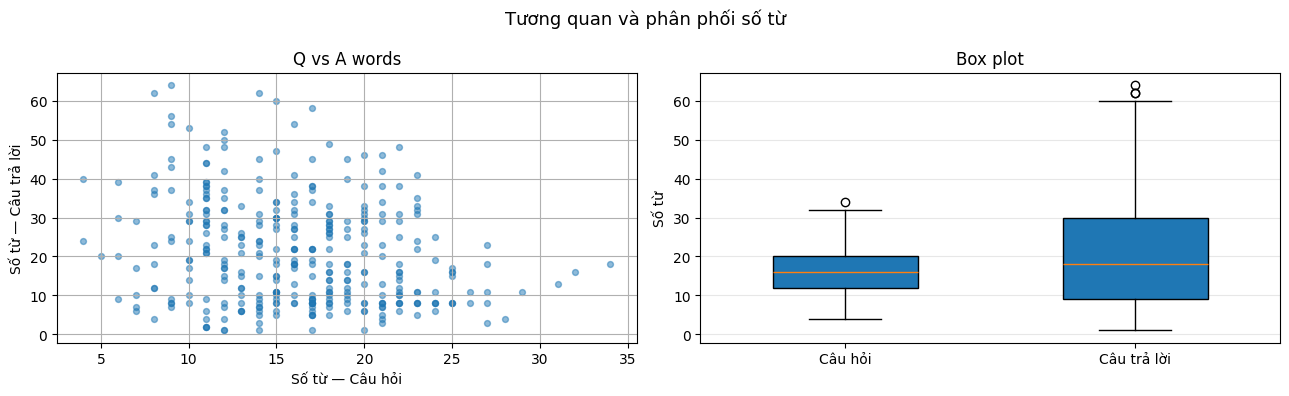

In [5]:
# Plot 2: Scatter + Box Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Tương quan và phân phối số từ', fontsize=13)

axes[0].scatter(df['q_words'], df['a_words'], alpha=0.5, s=18)
axes[0].set_xlabel('Số từ — Câu hỏi')
axes[0].set_ylabel('Số từ — Câu trả lời')
axes[0].set_title('Q vs A words')
axes[0].grid(True)

bp = axes[1].boxplot([df['q_words'], df['a_words']], patch_artist=True, widths=0.5)
axes[1].set_xticklabels(['Câu hỏi', 'Câu trả lời'])
axes[1].set_ylabel('Số từ')
axes[1].set_title('Box plot')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_2_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

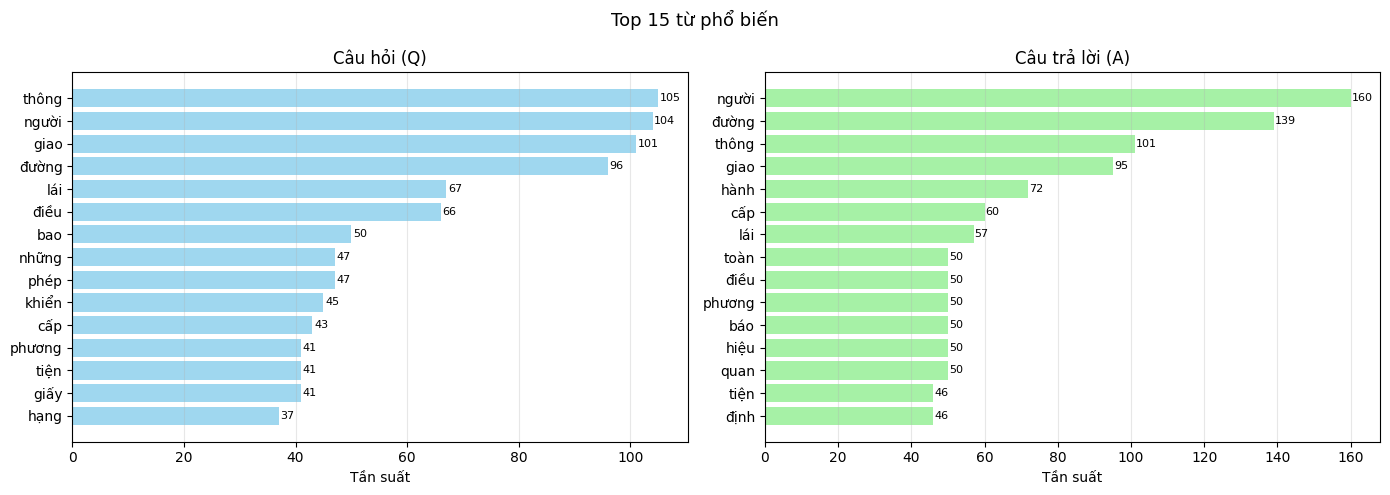

In [6]:
# Plot 3: Top 15 từ xuất hiện nhiều nhất
STOPWORDS = {
    'là', 'của', 'và', 'có', 'được', 'trong', 'các', 'theo', 'tại', 'khi',
    'đến', 'từ', 'với', 'về', 'này', 'một', 'cho', 'trên', 'đã', 'sẽ',
    'không', 'thì', 'đó', 'ra', 'hay', 'nào', 'phải', 'mà', 'do', 'vào',
    'câu', 'hỏi', 'trả', 'lời', 'hướng', 'dẫn'
}

def top_words(texts, n=15):
    words = []
    for t in texts:
        words += [w.lower() for w in re.findall(r'[\w]+', t) if len(w) > 2 and w.lower() not in STOPWORDS]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 15 từ phổ biến', fontsize=13)

for ax, texts, color, title in [
    (axes[0], df['Q'], 'skyblue',    'Câu hỏi (Q)'),
    (axes[1], df['A'], 'lightgreen', 'Câu trả lời (A)'),
]:
    top  = top_words(texts, 15)
    words, counts = zip(*top)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Tần suất')
    ax.grid(True, axis='x', alpha=0.3)
    for bar, count in zip(bars, list(reversed(counts))):
        ax.text(count + 0.3, bar.get_y() + bar.get_height() / 2, str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_3_topwords.png', dpi=130, bbox_inches='tight')
plt.show()

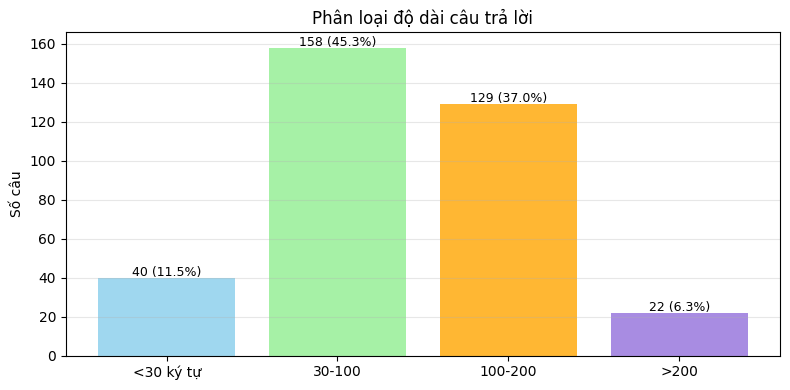


Thống kê tóm tắt
       q_chars  a_chars  q_words  a_words
count    349.0    349.0    349.0    349.0
mean      71.7     94.3     16.2     21.0
std       23.5     61.0      5.2     13.4
min       14.0      5.0      4.0      1.0
25%       54.0     40.0     12.0      9.0
50%       71.0     85.0     16.0     18.0
75%       89.0    133.0     20.0     30.0
max      149.0    288.0     34.0     64.0


In [7]:
# Plot 4: Phân loại độ dài câu trả lời theo nhóm
bins   = [0, 30, 100, 200, float('inf')]
labels = ['<30 ký tự', '30-100', '100-200', '>200']
df['a_bucket'] = pd.cut(df['a_chars'], bins=bins, labels=labels)
bucket_counts  = df['a_bucket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bucket_counts.index, bucket_counts.values, color=COLORS[:4], alpha=0.8)
for bar, val in zip(bars, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val} ({val / len(df) * 100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Phân loại độ dài câu trả lời')
ax.set_ylabel('Số câu')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_4_bucket.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nThống kê tóm tắt')
print(df[['q_chars', 'a_chars', 'q_words', 'a_words']].describe().round(1).to_string())

## 4 · Config

In [ ]:
BASE_MODEL = 'meta-llama/Llama-3.2-3B'
OUTPUT_DIR = 'model_A_no_rag_base'
DRIVE_PATH = '/content/drive/MyDrive'
GDRIVE_DIR = f'{DRIVE_PATH}/models/{OUTPUT_DIR}'
MAX_LENGTH = 1024
TEST_SIZE  = 0.15
SEED       = 42
FP16       = not USE_BF16
BF16       = USE_BF16

print(f'base_model : {BASE_MODEL}')
print(f'max_length : {MAX_LENGTH}')
print(f'test_size  : {TEST_SIZE}')
print(f'fp16       : {FP16}')
print(f'bf16       : {BF16}')
print(f'output_dir : {OUTPUT_DIR}')
print(f'drive_path : {DRIVE_PATH}')

base_model : meta-llama/Llama-3.2-3B
max_length : 1024
test_size  : 0.15
fp16       : True
bf16       : False
output_dir : model_A_no_rag_base
drive_path : /content/drive/MyDrive


## 5 · Tokenizer & Dataset

**Mô hình A — Không RAG, Không Fine-tune:** Prompt chỉ có câu hỏi, không inject context.  
Model dùng trực tiếp LLM gốc (zero-shot), không qua training.

In [9]:
from transformers import AutoTokenizer
from datasets import Dataset

# Load tokenizer của base model
print(f'Loading tokenizer: {BASE_MODEL}')

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    token=HF_TOKEN,
    use_fast=True
)

# Nếu model chưa có pad_token thì dùng eos_token thay thế
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Padding về bên phải (chuẩn cho causal LM)
tokenizer.padding_side = 'right'

print(f'Vocab size: {tokenizer.vocab_size:,}')


# Hàm lấy câu hỏi thuần từ field Q
def extract_question(raw_q: str) -> str:
    q = raw_q
    for prefix in ['Câu hỏi:\n', '### Câu hỏi:\n']:
        if q.startswith(prefix):
            q = q[len(prefix):]
            break
    for suffix in ['\n\n### Trả lời:\n', '\n### Trả lời:\n']:
        if q.endswith(suffix):
            q = q[:-len(suffix)]
            break
    return q.strip()


# Tạo prompt cho Model A (No RAG, No Fine-tune)
# Cùng prompt template với Model C để so sánh công bằng
def build_prompt_A(example: dict) -> dict:
    question = extract_question(example['Q'])

    prompt = (
        '### Hướng dẫn:\n'
        'Trả lời ngắn gọn, chính xác câu hỏi về luật giao thông đường bộ Việt Nam.\n\n'
        f'### Câu hỏi:\n{question}\n\n'
        '### Trả lời:\n'
    )

    return {
        'prompt': prompt,
        'answer': example['A']
    }


# Tạo prompt cho toàn bộ data
processed = [build_prompt_A(d) for d in raw_data]

# Chuyển sang HuggingFace Dataset và chia train/test
dataset = Dataset.from_list(processed)
split   = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

print(f'Train: {len(split["train"])}')
print(f'Test : {len(split["test"])}')

# In thử 1 sample
sample_0 = processed[0]
print('\nSample prompt:')
print(sample_0['prompt'])
print('\nSample answer:')
print(sample_0['answer'])

Loading tokenizer: meta-llama/Llama-3.2-3B


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Vocab size: 128,000
Train: 296
Test : 53

Sample prompt:
### Hướng dẫn:
Trả lời ngắn gọn, chính xác câu hỏi về luật giao thông đường bộ Việt Nam.

### Câu hỏi:
Luật Trật tự, an toàn giao thông đường bộ có hiệu lực thi hành từ ngày nào?

### Trả lời:


Sample answer:
Ngày 01 tháng 01 năm 2025


## 6 · Load Model Gốc (Không LoRA)

**Mô hình A** dùng trực tiếp base model, không áp dụng LoRA hay fine-tune.

In [10]:
from transformers import AutoModelForCausalLM

# Xóa cache GPU để tránh lỗi thiếu VRAM
torch.cuda.empty_cache()

print(f'Loading base model: {BASE_MODEL}')

# Load base model — KHÔNG áp dụng LoRA
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    token=HF_TOKEN,

    # Tự chọn precision theo GPU
    torch_dtype=torch.float16 if FP16 else torch.bfloat16,

    # Tự động phân bổ model lên GPU
    device_map='auto',

    # Giảm RAM CPU khi load model
    low_cpu_mem_usage=True,
)

# Chuyển model sang chế độ evaluation ngay (không train)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Total params : {total_params / 1e6:.1f}M')
print(f'VRAM used    : {torch.cuda.memory_allocated() / 1e9:.1f} GB')
print('Model A sẵn sàng (zero-shot, không fine-tune)')

Loading base model: meta-llama/Llama-3.2-3B


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Total params : 3212.7M
VRAM used    : 6.4 GB
Model A sẵn sàng (zero-shot, không fine-tune)


## 7 · Cấu hình Inference

> **Lưu ý:** Mô hình A **không training** — chỉ đánh giá trực tiếp trên LLM gốc.  
> Các tham số `TrainingArguments` và `LoraConfig` dưới đây được ghi lại để tham chiếu  
> và nhất quán với pipeline, nhưng **không được thực thi** trong notebook này.

In [11]:
# ============================================================
# Tham chiếu cấu hình — KHÔNG thực thi training ở Model A
# ============================================================
# Các giá trị này giống hệt Model C để đảm bảo so sánh công bằng.
#
# from transformers import TrainingArguments
# from peft import LoraConfig
#
# training_args = TrainingArguments(
#     output_dir=f"{DRIVE_PATH}/llm-rag-finetuned-v4",
#     num_train_epochs=3,
#     per_device_train_batch_size=1,
#     gradient_accumulation_steps=8,
#     gradient_checkpointing=True,
#     bf16=True,
#     learning_rate=2e-5,
#     logging_steps=10,
#     save_strategy="epoch",
#     prediction_loss_only=True,
# )
#
# config = LoraConfig(
#     r=8,
#     lora_alpha=8,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM"
# )

print('Model A: bỏ qua training — đánh giá trực tiếp LLM gốc (zero-shot)')
print(f'MAX_LENGTH = {MAX_LENGTH}')

Model A: bỏ qua training — đánh giá trực tiếp LLM gốc (zero-shot)
MAX_LENGTH = 1024


## 8 · Load Metrics

In [12]:
import evaluate

bleu_metric      = evaluate.load('bleu')
rouge_metric     = evaluate.load('rouge')
bertscore_metric = evaluate.load('bertscore')

print('Loaded: BLEU + ROUGE + BERTScore')

Loaded: BLEU + ROUGE + BERTScore


## 9 · Hàm Sinh Câu Trả Lời (Zero-shot)

In [13]:
# Hàm sinh câu trả lời từ LLM gốc (không fine-tune)
def generate_answer(
    question_raw: str,
    max_new_tokens: int = 128
) -> str:

    # Prompt cho Model A (No RAG, No Fine-tune)
    prompt = (
        '### Hướng dẫn:\n'
        'Trả lời ngắn gọn, chính xác câu hỏi về luật giao thông đường bộ Việt Nam. '
        'Không suy diễn, không thêm thông tin ngoài quy định pháp luật.\n\n'
        f'### Câu hỏi:\n{question_raw.strip()}\n\n'
        '### Trả lời:\n'
    )

    # Tokenize input
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH
    ).to('cuda')

    with torch.no_grad():
        outputs = model.generate(
            **inputs,

            # Giới hạn độ dài câu trả lời
            max_new_tokens=max_new_tokens,

            # QA pháp lý nên dùng deterministic
            # tránh hallucination
            do_sample=False,

            repetition_penalty=1.1,

            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Lấy phần model sinh ra (bỏ phần prompt)
    generated_tokens = outputs[0][inputs['input_ids'].shape[1]:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()


print('generate_answer() sẵn sàng')

generate_answer() sẵn sàng


## 10 · Đánh giá — BLEU / ROUGE / BERTScore

In [14]:
# Recreate test split đúng seed (khớp với Model C)
processed_list = [build_prompt_A(d) for d in raw_data]
all_ds  = Dataset.from_list(processed_list)
split2  = all_ds.train_test_split(test_size=TEST_SIZE, seed=SEED)
test_samples = split2['test']

print(f'Evaluating on {len(test_samples)} samples (zero-shot)...')

# ===================================
# Generate predictions
# ===================================

preds = []
refs  = []

for i, sample in enumerate(test_samples):
    q_text = sample['prompt'] \
        .split('### Câu hỏi:')[-1] \
        .split('### Trả lời')[0] \
        .strip()

    preds.append(generate_answer(q_text))
    refs.append(sample['answer'])

    if (i + 1) % 10 == 0:
        print(f'  {i + 1}/{len(test_samples)}')

# ===================================
# Compute metrics
# ===================================

bleu = bleu_metric.compute(
    predictions=preds,
    references=[[x] for x in refs]
)

rouge = rouge_metric.compute(
    predictions=preds,
    references=refs
)

bscore = bertscore_metric.compute(
    predictions=preds,
    references=refs,
    lang='vi'
)

results = {
    'BLEU'     : round(bleu['bleu'], 4),
    'ROUGE-1'  : round(rouge['rouge1'], 4),
    'ROUGE-2'  : round(rouge['rouge2'], 4),
    'ROUGE-L'  : round(rouge['rougeL'], 4),
    'BERTScore': round(sum(bscore['f1']) / len(bscore['f1']), 4),
}

# ===================================
# In kết quả
# ===================================

print('\nKết quả Mô hình A (No RAG + No Fine-tune — Zero-shot)\n')
for k, v in results.items():
    print(f'{k:12s}: {v:.4f}')

# ===================================
# Lưu file JSON
# ===================================

import os
os.makedirs(GDRIVE_DIR, exist_ok=True)

with open('results_model_A.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

import shutil
shutil.copy('results_model_A.json', f'{GDRIVE_DIR}/results_model_A.json')
print('\nresults_model_A.json saved')

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluating on 53 samples (zero-shot)...
  10/53
  20/53
  30/53
  40/53
  50/53


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Kết quả Mô hình A (No RAG + No Fine-tune — Zero-shot)

BLEU        : 0.0228
ROUGE-1     : 0.3280
ROUGE-2     : 0.1542
ROUGE-L     : 0.2411
BERTScore   : 0.6862

results_model_A.json saved


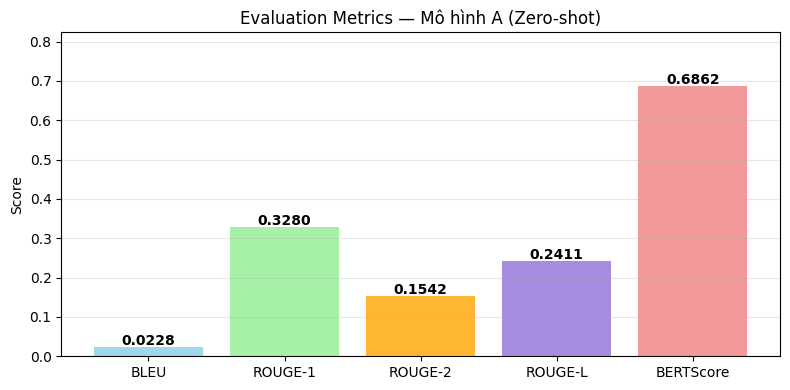

In [15]:
# Vẽ biểu đồ các metric đánh giá cuối cùng
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    list(results.keys()),
    list(results.values()),
    color=COLORS[:len(results)],
    alpha=0.8
)

for bar, val in zip(bars, results.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_ylim(0, max(results.values()) * 1.2)
ax.set_title('Evaluation Metrics — Mô hình A (Zero-shot)')
ax.set_ylabel('Score')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eval_metrics_A.png', dpi=130, bbox_inches='tight')
shutil.copy('eval_metrics_A.png', f'{GDRIVE_DIR}/eval_metrics_A.png')
plt.show()

## 11 · Qualitative — Xem ví dụ dự đoán

In [16]:
# Hiển thị một vài ví dụ dự đoán để đánh giá chất lượng thực tế

for i in range(min(5, len(test_samples))):
    q_text = test_samples[i]['prompt'] \
        .split('### Câu hỏi:')[-1] \
        .split('### Trả lời')[0] \
        .strip()

    print(f'--- Sample {i+1} ---')
    print(f'Q   : {q_text}')
    print(f'Gold: {test_samples[i]["answer"]}')
    print(f'Pred: {preds[i]}')
    print()

--- Sample 1 ---
Q   : Khi chuyển hướng phải bảo đảm những điều kiện gì?
Gold: Khi bảo đảm an toàn, không gây trở ngại cho người và phương tiện khác mới được chuyển hướng.
Pred: - Khi chuyển hướng phải bảo đảm: 
    - Đi đúng làn đường
    - Đi đúng chiều hướng
    - Đi đúng tốc độ
    - Đi đúng khoảng cách với xe trước

### Giải thích:
- Khi chuyển hướng phải, người lái xe phải đảm bảo đi đúng làn đường, đi đúng chiều hướng, đi đúng tốc độ và đi đúng khoảng cách với xe trước.
- Nếu không đảm bảo được các điều kiện trên thì sẽ vi phạm luật giao thông đường bộ.

### Lưu ý:
- Khi chuyển hướng phải, người lái xe phải đảm bảo đi đúng làn đường, đi đúng chiều hướng

--- Sample 2 ---
Q   : Làm gián đoạn hoạt động hoặc làm sai lệch dữ liệu thiết bị giám sát hành trình có bị nghiêm cấm không?
Gold: Có, đây là hành vi bị nghiêm cấm.
Pred: - Có
- Theo Điều 4 Nghị định số 100/2019/NĐ-CP ngày 20 tháng 11 năm 2019 của Chính phủ quy định xử phạt vi phạm hành chính trong lĩnh vực giao thông đường bộ 

## 12 · Demo — Hỏi thủ công

In [17]:
# Demo hỏi thủ công với LLM gốc (zero-shot)
test_qs = [
    'Tốc độ tối đa cho phép của xe máy trong khu vực đông dân cư là bao nhiêu?',
    'Vượt đèn đỏ bị phạt bao nhiêu tiền?',
    'Người điều khiển xe mô tô phải đáp ứng điều kiện gì?'
]

for q in test_qs:
    ans = generate_answer(q)
    print(f'Q: {q}')
    print(f'A: {ans}')
    print()

Q: Tốc độ tối đa cho phép của xe máy trong khu vực đông dân cư là bao nhiêu?
A: Tốc độ tối đa cho phép của xe máy trong khu vực đông dân cư là 40 km/h.

Q: Vượt đèn đỏ bị phạt bao nhiêu tiền?
A: Theo quy định tại Điều 15 Nghị định số 100/2019/NĐ-CP ngày 20 tháng 11 năm 2019 của Chính phủ quy định xử phạt vi phạm hành chính trong lĩnh vực giao thông đường bộ thì người vượt đèn đỏ trên đường bộ sẽ bị phạt từ 1 triệu đồng đến 2 triệu đồng.

Q: Người điều khiển xe mô tô phải đáp ứng điều kiện gì?
A: Người điều khiển xe mô tô phải có giấy phép lái xe hạng A1 hoặc B1 và đủ 18 tuổi trở lên.



In [18]:
# Test một câu hỏi tự nhập
MY_QUESTION = 'Người đi xe đạp điện có cần đội mũ bảo hiểm không?'
print(f'Q: {MY_QUESTION}')
print(f'A: {generate_answer(MY_QUESTION)}')

Q: Người đi xe đạp điện có cần đội mũ bảo hiểm không?
A: Có phải đội mũ bảo hiểm khi tham gia giao thông đường bộ theo quy định tại Điều 5 Nghị định số 100/2019/NĐ-CP ngày 20 tháng 11 năm 2019 của Chính phủ quy định chi tiết và hướng dẫn thi hành một số điều của Luật Giao thông đường bộ.
